In [ ]:

import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 


In [3]:
df=pd.read_csv(r"C:\Users\Shree\OneDrive\Desktop\CBZ Practice Datasets\Mall_Customers.csv")

In [4]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

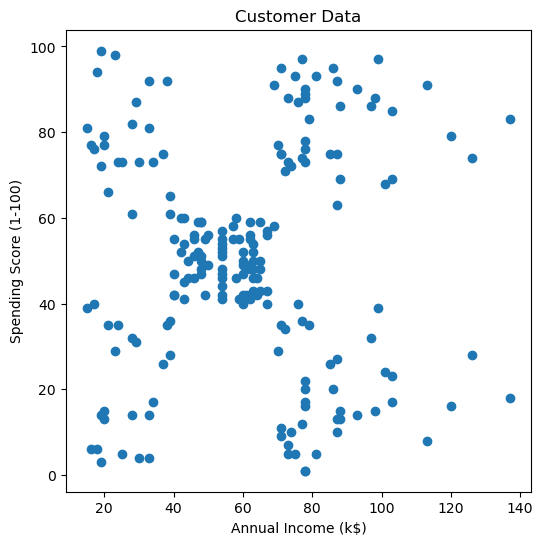

In [6]:
# visualize the dataset before applying K-Means clustering

plt.figure(figsize=(6,6))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Data")
plt.show()

In [7]:
kmeans = KMeans( n_clusters=4, random_state=42 )

In [22]:
kmeans.fit(X)

KMeans(n_clusters=4, random_state=42)

In [28]:
# Cluster Labels 
df["Cluster"]=kmeans.labels_

In [30]:
# Centroids 
centroids=kmeans.cluster_centers_

In [31]:
print("Centroids") 
print(centroids)

Centroids
[[26.30434783 20.91304348]
 [86.53846154 82.12820513]
 [87.         18.63157895]
 [48.26       56.48      ]]


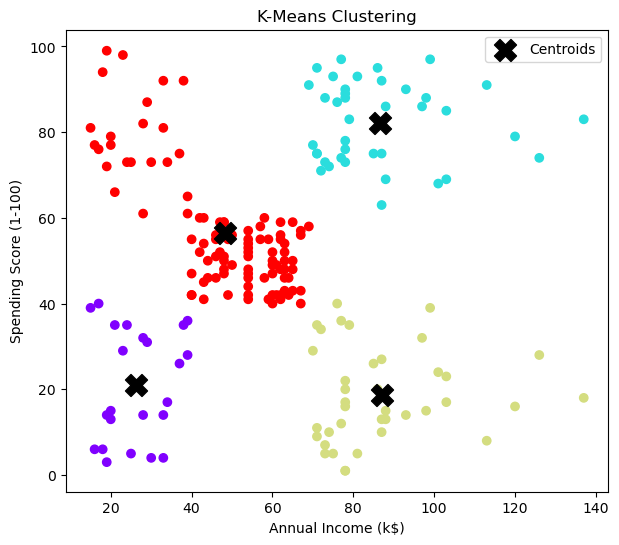

In [69]:
plt.figure(figsize=(7,6)) 

plt.scatter( df["Annual Income (k$)"], 
             df["Spending Score (1-100)"], 
             c=df["Cluster"],             #----> separates the data points based on the assigned clusters.
             cmap="rainbow"
           )
plt.scatter( centroids[:,0], 
            centroids[:,1], 
            color="black", 
            marker="X",
            s=250,
            label="Centroids" 
           )

plt.title("K-Means Clustering") 
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)") 
plt.legend()
plt.show()

In [34]:
# Within-Cluster Sum of Squares
# If the data points are close to their centroid --> low WCSS

print("Inertia (WCSS):",kmeans.inertia_)

Inertia (WCSS): 73679.78903948836


C:\Users\Shree\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


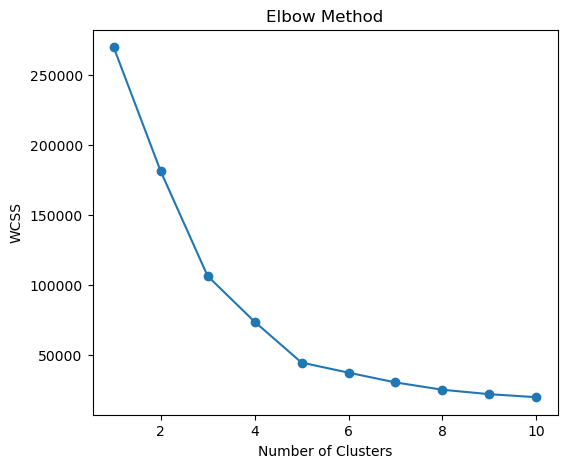

In [68]:
 #  Elbow Method ---> find the optimal number of clusters for K-Means
wcss=[] 
    
for i in range(1,11):
    model=KMeans( n_clusters=i, random_state=42 )
    model.fit(df[["Annual Income (k$)","Spending Score (1-100)"]]) 
    wcss.append(model.inertia_) 
        
plt.figure(figsize=(6,5))
plt.plot( range(1,11), wcss, marker="o" )
plt.title("Elbow Method") 
plt.xlabel("Number of Clusters") 
plt.ylabel("WCSS") 
plt.show()